# KAN-Driven Phase-Spectrum Analysis for Deepfake Detection
## Master Notebook — All Stages (1-7)
Run all cells sequentially on Kaggle with GPU T4.

**Expected Runtime:** ~1.5-2 hours total

| Stage | Description | Time |
|-------|------------|------|
| 1 | Phase Extraction | ~2 min |
| 2 | Dataset Integration | ~5-8 min |
| 3 | PCA & MLP Baseline | ~3-5 min |
| 4 | KAN-Phase | ~5-8 min |
| 5 | CNN & ViT Baselines | ~15-20 min |
| 6 | Ablations & Robustness | ~40-60 min |
| 7 | Evaluation & Interpretability | ~5-7 min |

In [ ]:
!pip install pykan kagglehub -q

# Stage 1: Preprocessing & Phase Spectrum Extraction
**Project:** KAN-Driven Phase-Spectrum Analysis for Deepfake Detection  
**Environment:** Kaggle / Local

In [2]:
import numpy as np, cv2, os, glob
import matplotlib.pyplot as plt
from typing import Dict, Tuple, Optional
import kagglehub

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# --- Guaranteed path detection ---
INPUT_DIR = kagglehub.dataset_download('awsaf49/artifact-dataset')
OUTPUT_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else os.path.join(INPUT_DIR, '..')

print(f'Dataset downloaded to: {INPUT_DIR}')
print(f'Contents:')
for item in sorted(os.listdir(INPUT_DIR))[:15]:
    f = os.path.join(INPUT_DIR, item)
    print(f'  {"[DIR]" if os.path.isdir(f) else "[FILE]"} {item}')

Dataset downloaded to: /kaggle/input/datasets/awsaf49/artifact-dataset
Contents:
  [DIR] afhq
  [DIR] big_gan
  [DIR] celebahq
  [DIR] cips
  [DIR] coco
  [DIR] cycle_gan
  [DIR] ddpm
  [DIR] denoising_diffusion_gan
  [DIR] diffusion_gan
  [DIR] face_synthetics
  [DIR] ffhq
  [DIR] gansformer
  [DIR] gau_gan
  [DIR] generative_inpainting
  [DIR] glide


In [3]:
# Cell 2: PhaseSpectrumExtractor

class PhaseSpectrumExtractor:
    _LUMA_R, _LUMA_G, _LUMA_B = 0.2989, 0.5870, 0.1140
    def __init__(self, target_size=(256, 256)):
        self.target_size = target_size
    def load_image(self, path):
        bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if bgr is None: raise ValueError(f'Cannot read: {path}')
        return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    def rgb_to_grayscale(self, rgb):
        f = rgb.astype(np.float64)
        return self._LUMA_R*f[:,:,0] + self._LUMA_G*f[:,:,1] + self._LUMA_B*f[:,:,2]
    def process(self, image_path):
        rgb = self.load_image(image_path)
        gray = self.rgb_to_grayscale(rgb)
        gray_r = cv2.resize(gray, (self.target_size[1], self.target_size[0]), interpolation=cv2.INTER_CUBIC)
        fft_shifted = np.fft.fftshift(np.fft.fft2(gray_r))
        phase = np.angle(fft_shifted)
        p_min, p_max = phase.min(), phase.max()
        phase_norm = (phase - p_min) / (p_max - p_min) if p_max > p_min else np.zeros_like(phase)
        mag_log = np.log1p(np.abs(fft_shifted))
        return {'original_rgb': rgb, 'grayscale_resized': gray_r,
                'magnitude_log': mag_log, 'phase_normalized': phase_norm}

print('PhaseSpectrumExtractor defined.')

PhaseSpectrumExtractor defined.


Found: /kaggle/input/datasets/awsaf49/artifact-dataset/cips/cips/cips-churces/img000000.jpg
Phase: (256, 256), range [0,1] ✓


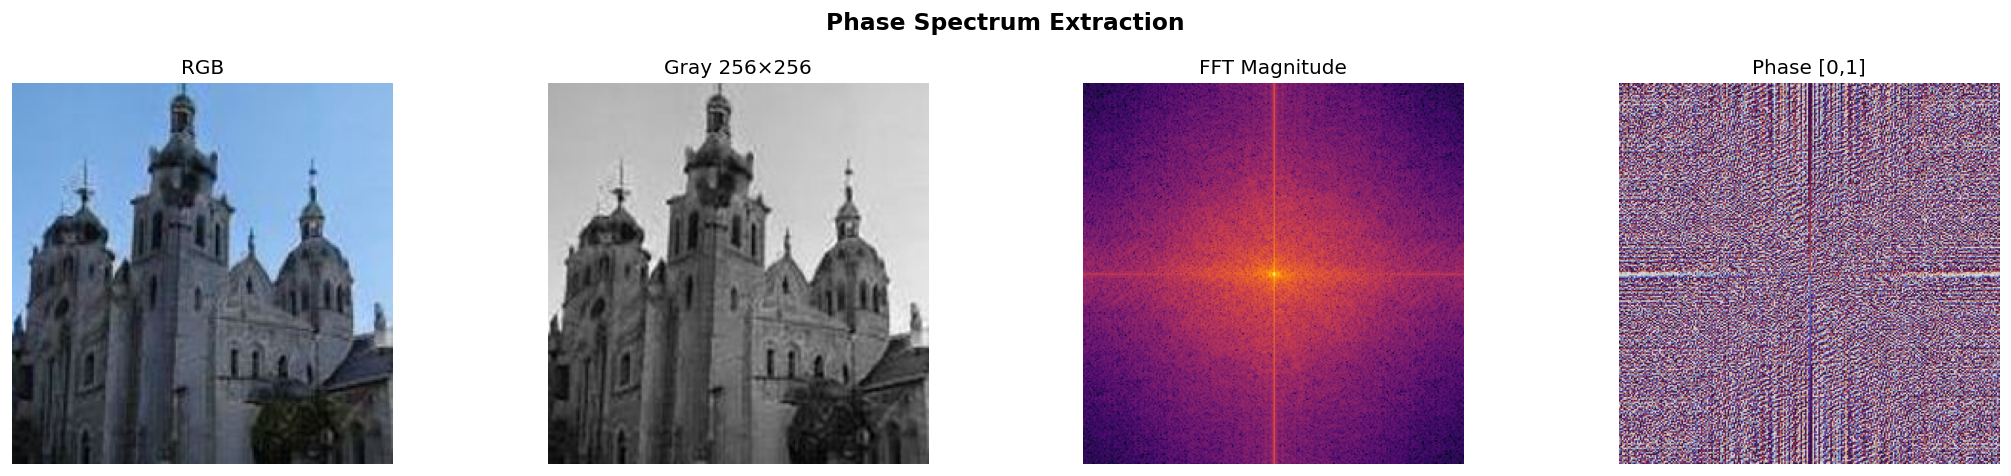

In [4]:
# Cell 3: Find ONE Image & Run
sample_image = None
for root, dirs, files in os.walk(INPUT_DIR):
    for f in sorted(files):
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            sample_image = os.path.join(root, f)
            break
    if sample_image:
        break

print(f'Found: {sample_image}')
extractor = PhaseSpectrumExtractor()
results = extractor.process(sample_image)

assert results['phase_normalized'].shape == (256, 256)
print(f'Phase: {results["phase_normalized"].shape}, range [0,1] ✓')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Phase Spectrum Extraction', fontsize=14, fontweight='bold')
axes[0].imshow(results['original_rgb']); axes[0].set_title('RGB'); axes[0].axis('off')
axes[1].imshow(results['grayscale_resized'], cmap='gray'); axes[1].set_title('Gray 256×256'); axes[1].axis('off')
axes[2].imshow(results['magnitude_log'], cmap='inferno'); axes[2].set_title('FFT Magnitude'); axes[2].axis('off')
axes[3].imshow(results['phase_normalized'], cmap='twilight', vmin=0, vmax=1); axes[3].set_title('Phase [0,1]'); axes[3].axis('off')
plt.tight_layout(); plt.show()

# Stage 2: Dataset Integration & Phase Analysis
**Project:** KAN-Driven Phase-Spectrum Analysis for Deepfake Detection

In [ ]:
import numpy as np, pandas as pd, cv2, os, glob
from typing import Dict, List, Tuple, Optional
from scipy import stats
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.notebook import tqdm
import kagglehub

%matplotlib inline
plt.rcParams['figure.dpi'] = 120; sns.set_style('whitegrid')

INPUT_DIR = kagglehub.dataset_download('awsaf49/artifact-dataset')
OUTPUT_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else './output'
CACHE_DIR = os.path.join(OUTPUT_DIR, 'phase_cache')
os.makedirs(CACHE_DIR, exist_ok=True)

print(f'Dataset: {INPUT_DIR}')
print(f'Cache  : {CACHE_DIR}')
for item in sorted(os.listdir(INPUT_DIR))[:15]:
    f = os.path.join(INPUT_DIR, item)
    print(f'  {"[DIR]" if os.path.isdir(f) else "[FILE]"} {item}')

In [ ]:
# Cell 2: Dataset Discovery
class DatasetExplorer:
    def __init__(self, root): self.root = root; self.metadata_df = None
    def load_metadata(self):
        meta_files = glob.glob(os.path.join(self.root, '**', 'metadata.csv'), recursive=True)
        print(f'Found {len(meta_files)} metadata.csv files')
        all_dfs = []
        for mf in meta_files:
            gen_dir = os.path.dirname(mf)
            gen_name = os.path.basename(gen_dir)
            df = pd.read_csv(mf)
            df['generator'] = gen_name
            df['image_path'] = df['image_path'].apply(lambda p: os.path.join(gen_dir, p) if not os.path.isabs(p) else p)
            all_dfs.append(df)
            print(f'  {len(df):>6d} from [{gen_name}]')
        if not all_dfs:
            return self._fallback()
        self.metadata_df = pd.concat(all_dfs, ignore_index=True)
        if 'target' in self.metadata_df.columns:
            self.metadata_df['target'] = self.metadata_df['target'].astype(int)
        return self.metadata_df
    def _fallback(self):
        exts = {'.png','.jpg','.jpeg','.bmp','.webp'}
        recs = []
        for root, _, files in os.walk(self.root):
            for f in files:
                if os.path.splitext(f)[1].lower() in exts:
                    full = os.path.join(root, f)
                    parts = os.path.relpath(root, self.root).lower().split(os.sep)
                    is_real = 'real' in parts
                    gen = 'real' if is_real else (parts[-1] if parts[-1] != '.' else 'unknown')
                    recs.append({'image_path':full,'target':0 if is_real else 1,'generator':gen})
        self.metadata_df = pd.DataFrame(recs)
        print(f'Fallback scan: {len(self.metadata_df)} images')
        return self.metadata_df
    def summary(self):
        df = self.metadata_df
        print(f'Total: {len(df):,}  Real: {(df["target"]==0).sum():,}  Fake: {(df["target"]==1).sum():,}')
        for gen, cnt in df['generator'].value_counts().items():
            lbl = 'REAL' if df[df['generator']==gen]['target'].mode().iloc[0]==0 else 'FAKE'
            print(f'  {gen:30s}: {cnt:>6,} [{lbl}]')

explorer = DatasetExplorer(INPUT_DIR)
metadata_df = explorer.load_metadata()
explorer.summary()

In [ ]:
# Cell 3: Batch Phase Extraction
class PhaseSpectrumExtractor:
    _LR,_LG,_LB = 0.2989,0.5870,0.1140
    def __init__(self, size=(256,256)): self.size = size
    def process_single(self, path):
        try:
            bgr = cv2.imread(path, cv2.IMREAD_COLOR)
            if bgr is None: return None
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float64)
            gray = self._LR*rgb[:,:,0]+self._LG*rgb[:,:,1]+self._LB*rgb[:,:,2]
            gray = cv2.resize(gray, (self.size[1],self.size[0]), interpolation=cv2.INTER_CUBIC)
            fft = np.fft.fftshift(np.fft.fft2(gray))
            phase = np.angle(fft)
            mn,mx = phase.min(),phase.max()
            return (phase-mn)/(mx-mn) if mx>mn else np.zeros(self.size)
        except: return None

class BatchPhaseExtractor:
    def __init__(self, cache_dir): self.cache_dir=cache_dir; self.ext=PhaseSpectrumExtractor(); os.makedirs(cache_dir, exist_ok=True)
    def extract(self, df, n_per_gen=50, use_cache=True):
        cf = os.path.join(self.cache_dir, f'phase_maps_n{n_per_gen}.npy')
        if use_cache and os.path.exists(cf):
            print(f'Loading cache: {cf}')
            r = np.load(cf, allow_pickle=True).item()
            for g,m in r.items(): print(f'  {g:30s}: {len(m)} maps')
            return r
        results = {}
        for gen in sorted(df['generator'].unique()):
            gdf = df[df['generator']==gen]
            if n_per_gen>0 and len(gdf)>n_per_gen: gdf=gdf.sample(n=n_per_gen, random_state=42)
            maps, fail = [], 0
            for p in tqdm(gdf['image_path'].values, desc=f'{gen[:25]:25s}'):
                m = self.ext.process_single(p)
                if m is not None: maps.append(m)
                else: fail+=1
            if maps: results[gen]=np.array(maps); print(f'  {gen}: {len(maps)} ok, {fail} fail')
        np.save(cf, results); print(f'Saved: {cf}')
        return results

N_SAMPLES = 50
batch = BatchPhaseExtractor(CACHE_DIR)
phase_results = batch.extract(metadata_df, n_per_gen=N_SAMPLES)
print('\nSummary:')
for g,m in sorted(phase_results.items()): print(f'  {g:30s}: {m.shape}')

In [ ]:
# Cell 4: Mean Phase Maps
real_gens, fake_gens = [], []
for gen in phase_results:
    gdf = metadata_df[metadata_df['generator']==gen]
    if len(gdf)>0 and gdf['target'].mode().iloc[0]==0: real_gens.append(gen)
    else: fake_gens.append(gen)
if not real_gens:
    real_gens=[g for g in phase_results if 'real' in g.lower()]
    fake_gens=[g for g in phase_results if g not in real_gens]

mean_maps = {g: np.mean(m, axis=0) for g,m in phase_results.items()}
real_all = np.concatenate([phase_results[g] for g in real_gens if g in phase_results])
real_mean = np.mean(real_all, axis=0) if len(real_all)>0 else None
print(f'Real: {real_gens}\nFake: {fake_gens}')

disp = fake_gens[:8]
nc = min(len(disp)+1, 9)
fig,axes = plt.subplots(2, nc, figsize=(3*nc, 6))
fig.suptitle('Per-Generator Mean Phase Maps', fontweight='bold', y=1.02)
if real_mean is not None:
    axes[0,0].imshow(real_mean, cmap='twilight', vmin=0, vmax=1); axes[0,0].set_title('REAL',color='green',fontweight='bold'); axes[0,0].axis('off')
    axes[1,0].text(0.5,0.5,'REF',ha='center',va='center',transform=axes[1,0].transAxes); axes[1,0].axis('off')
for i,g in enumerate(disp):
    c=i+1
    if c>=nc: break
    axes[0,c].imshow(mean_maps[g],cmap='twilight',vmin=0,vmax=1); axes[0,c].set_title(g[:15],fontsize=8); axes[0,c].axis('off')
    if real_mean is not None:
        diff=np.abs(mean_maps[g]-real_mean)
        axes[1,c].imshow(diff,cmap='hot'); axes[1,c].set_title(f'|diff|',fontsize=8); axes[1,c].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# Cell 5: KS Tests
real_samples = []
for g in real_gens:
    if g in phase_results:
        for m in phase_results[g]:
            flat=m.flatten(); idx=np.random.RandomState(42).choice(len(flat),size=min(5000,len(flat)),replace=False)
            real_samples.append(flat[idx])
real_dist = np.concatenate(real_samples)

ks_recs = []
for g in sorted(fake_gens):
    if g not in phase_results: continue
    fs = []
    for m in phase_results[g]:
        flat=m.flatten(); idx=np.random.RandomState(42).choice(len(flat),size=min(5000,len(flat)),replace=False)
        fs.append(flat[idx])
    fd = np.concatenate(fs)
    ks,pv = stats.ks_2samp(real_dist, fd)
    ks_recs.append({'generator':g,'n_images':len(phase_results[g]),'ks_stat':round(ks,6),'p_value':pv,'significant':'YES' if pv<0.05 else 'NO'})

ks_df = pd.DataFrame(ks_recs).sort_values('ks_stat',ascending=False)
print('KS Test Results:'); print(ks_df.to_string(index=False))
n_sig = (ks_df['significant']=='YES').sum()
print(f'\n{n_sig}/{len(ks_df)} generators significant (p<0.05)')
if n_sig>0: print('CONCLUSION: Phase-based detection IS viable.')

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,max(4,len(ks_df)*0.5)))
fig.suptitle('KS Test: Real vs Fake Phase', fontweight='bold')
colors=['#e74c3c' if s=='YES' else '#95a5a6' for s in ks_df['significant']]
ax1.barh(ks_df['generator'],ks_df['ks_stat'],color=colors); ax1.set_xlabel('KS Stat'); ax1.invert_yaxis()
pv=ks_df['p_value'].replace(0,1e-300)
ax2.barh(ks_df['generator'],-np.log10(pv),color=colors); ax2.axvline(x=-np.log10(0.05),color='k',ls='--'); ax2.set_xlabel('-log10(p)'); ax2.invert_yaxis()
plt.tight_layout(); plt.show()

# Stage 3: PCA & MLP-Phase Baseline (B3)
**Project:** KAN-Driven Phase-Spectrum Analysis for Deepfake Detection

In [ ]:
CONFIG = {'n_pca':128, 'hidden':[256,128,64], 'drop':0.3, 'lr':1e-3, 'wd':1e-4, 'bs':64, 'epochs':50, 'patience':10}

In [ ]:
# Cell 2: Load Phase Maps
cache_files = sorted(glob.glob(os.path.join(CACHE_DIR, 'phase_maps_*.npy')))
if not cache_files: raise FileNotFoundError(f'No cache in {CACHE_DIR}. Run Stage 2!')
phase_results = np.load(cache_files[-1], allow_pickle=True).item()

meta_files = glob.glob(os.path.join(INPUT_DIR, '**', 'metadata.csv'), recursive=True)
metadata_df = pd.concat([pd.read_csv(mf).assign(generator=os.path.basename(os.path.dirname(mf))) for mf in meta_files], ignore_index=True) if meta_files else None

X_list, y_list = [], []
for gen,maps in phase_results.items():
    if metadata_df is not None:
        gdf=metadata_df[metadata_df['generator']==gen]; is_real=len(gdf)>0 and gdf['target'].mode().iloc[0]==0
    else: is_real='real' in gen.lower()
    for m in maps: X_list.append(m.flatten()); y_list.append(0 if is_real else 1)
X_raw=np.array(X_list,dtype=np.float32); y=np.array(y_list,dtype=np.int64)
print(f'Features: {X_raw.shape}  Real:{(y==0).sum()} Fake:{(y==1).sum()}')

In [ ]:
# Cell 3: PCA
scaler=StandardScaler(); X_scaled=scaler.fit_transform(X_raw)
n_max=min(X_scaled.shape[0],X_scaled.shape[1],500)
pca_full=PCA(n_components=n_max,random_state=42); pca_full.fit(X_scaled)
cum_var=np.cumsum(pca_full.explained_variance_ratio_)
fig,(a1,a2)=plt.subplots(1,2,figsize=(14,5))
a1.bar(range(1,min(51,n_max+1)),pca_full.explained_variance_ratio_[:50],color='steelblue')
a1.set_xlabel('Component'); a1.set_title('Individual Variance')
a2.plot(range(1,len(cum_var)+1),cum_var,lw=2); a2.axhline(0.95,color='r',ls='--',label='95%')
nc=CONFIG['n_pca']
if nc<=len(cum_var): a2.axvline(nc,color='g',ls=':',label=f'n={nc} ({cum_var[nc-1]:.1%})')
a2.legend(); a2.set_xlim(0,min(300,n_max)); plt.tight_layout(); plt.show()
pca=PCA(n_components=nc,random_state=42); X_pca=pca.fit_transform(X_scaled)
print(f'PCA: {X_pca.shape}, var={pca.explained_variance_ratio_.sum():.3f}')
np.save(os.path.join(MODEL_DIR,'pca_components.npy'),pca.components_)

In [ ]:
# Cell 4: MLP Training
class MLPPhase(nn.Module):
    def __init__(self,inp,hids,drop=0.3):
        super().__init__()
        layers=[]; prev=inp
        for h in hids: layers.extend([nn.Linear(prev,h),nn.BatchNorm1d(h),nn.ReLU(True),nn.Dropout(drop)]); prev=h
        layers.append(nn.Linear(prev,1)); self.net=nn.Sequential(*layers)
    def forward(self,x): return self.net(x).squeeze(-1)

X_tv,X_te,y_tv,y_te=train_test_split(X_pca,y,test_size=0.2,stratify=y,random_state=42)
X_tr,X_va,y_tr,y_va=train_test_split(X_tv,y_tv,test_size=0.15,stratify=y_tv,random_state=42)
print(f'Train:{len(X_tr)} Val:{len(X_va)} Test:{len(X_te)}')
trl=DataLoader(TensorDataset(torch.FloatTensor(X_tr),torch.LongTensor(y_tr)),batch_size=64,shuffle=True)
val=DataLoader(TensorDataset(torch.FloatTensor(X_va),torch.LongTensor(y_va)),batch_size=64)
tel=DataLoader(TensorDataset(torch.FloatTensor(X_te),torch.LongTensor(y_te)),batch_size=64)

model=MLPPhase(nc,CONFIG['hidden'],CONFIG['drop']).to(DEVICE)
n_params=sum(p.numel() for p in model.parameters()); print(f'MLP params: {n_params:,}')
crit=nn.BCEWithLogitsLoss(); opt=optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-4)
sched=optim.lr_scheduler.ReduceLROnPlateau(opt,mode='max',factor=0.5,patience=5)
hist={'tl':[],'vl':[],'ta':[],'va':[]}
best,pat=0.0,0
for ep in tqdm(range(CONFIG['epochs']),desc='MLP'):
    model.train(); tl,tp,tt=0,[],[]
    for xb,yb in trl:
        xb,yb=xb.to(DEVICE),yb.float().to(DEVICE); opt.zero_grad()
        lo=model(xb); l=crit(lo,yb); l.backward(); opt.step()
        tl+=l.item()*len(yb); tp.append(torch.sigmoid(lo).detach().cpu().numpy()); tt.append(yb.cpu().numpy())
    tp,tt=np.concatenate(tp),np.concatenate(tt)
    ta=roc_auc_score(tt,tp) if len(np.unique(tt))>1 else 0
    model.eval(); vl,vp,vt=0,[],[]
    with torch.no_grad():
        for xb,yb in val:
            xb,yb=xb.to(DEVICE),yb.float().to(DEVICE); lo=model(xb)
            vl+=crit(lo,yb).item()*len(yb); vp.append(torch.sigmoid(lo).cpu().numpy()); vt.append(yb.cpu().numpy())
    vp,vt=np.concatenate(vp),np.concatenate(vt)
    va2=roc_auc_score(vt,vp) if len(np.unique(vt))>1 else 0
    sched.step(va2)
    hist['tl'].append(tl/len(trl.dataset)); hist['vl'].append(vl/len(val.dataset)); hist['ta'].append(ta); hist['va'].append(va2)
    if va2>best: best=va2;pat=0;torch.save(model.state_dict(),os.path.join(MODEL_DIR,'mlp_b3_best.pth'))
    else:
        pat+=1
        if pat>=CONFIG['patience']: print(f'Early stop ep {ep+1}'); break
model.load_state_dict(torch.load(os.path.join(MODEL_DIR,'mlp_b3_best.pth'),weights_only=True))

In [ ]:
# Cell 5: Evaluation
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,5))
ep=range(1,len(hist['tl'])+1)
a1.plot(ep,hist['tl'],label='Train');a1.plot(ep,hist['vl'],label='Val');a1.set_title('Loss');a1.legend()
a2.plot(ep,hist['ta'],label='Train');a2.plot(ep,hist['va'],label='Val');a2.set_title('AUC');a2.legend()
plt.tight_layout();plt.show()

model.eval();ap,at=[],[]
with torch.no_grad():
    for xb,yb in tel: ap.append(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy());at.append(yb.numpy())
tp,tt=np.concatenate(ap),np.concatenate(at)
tacc=accuracy_score(tt,(tp>0.5).astype(int)); tauc=roc_auc_score(tt,tp)
print(f'MLP-Phase(B3): Acc={tacc:.4f} AUC={tauc:.4f} Params={n_params:,}')
print(classification_report(tt,(tp>0.5).astype(int),target_names=['Real','Fake']))

fig,(a1,a2)=plt.subplots(1,2,figsize=(12,5))
fpr,tpr,_=roc_curve(tt,tp); a1.plot(fpr,tpr,lw=2,label=f'AUC={tauc:.3f}');a1.plot([0,1],[0,1],'k--',alpha=0.3);a1.legend();a1.set_title('ROC')
cm=confusion_matrix(tt,(tp>0.5).astype(int))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=a2,xticklabels=['Real','Fake'],yticklabels=['Real','Fake']);a2.set_title('Confusion')
plt.tight_layout();plt.show()
with open(os.path.join(MODEL_DIR,'results_b3.json'),'w') as f:
    json.dump({'model':'MLP-Phase (B3)','test_accuracy':float(tacc),'test_auc':float(tauc),'n_parameters':n_params},f,indent=2)
print('B3 saved.')

# Stage 4: KAN-Phase Implementation
**Project:** KAN-Driven Phase-Spectrum Analysis for Deepfake Detection

In [ ]:
CONFIG = {'n_pca':128,'width':[128,64,32,1],'grid':5,'k':3,'lr':1e-3,'wd':1e-4,'bs':64,'epochs':50,'patience':10}

In [ ]:
# Cell 2: Load & Prep
cache_files = sorted(glob.glob(os.path.join(CACHE_DIR,'phase_maps_*.npy')))
phase_results = np.load(cache_files[-1], allow_pickle=True).item()
meta_files = glob.glob(os.path.join(INPUT_DIR,'**','metadata.csv'), recursive=True)
mdf = pd.concat([pd.read_csv(mf).assign(generator=os.path.basename(os.path.dirname(mf))) for mf in meta_files], ignore_index=True) if meta_files else None
X_l,y_l=[],[]
for g,maps in phase_results.items():
    if mdf is not None: gdf=mdf[mdf['generator']==g]; ir=len(gdf)>0 and gdf['target'].mode().iloc[0]==0
    else: ir='real' in g.lower()
    for m in maps: X_l.append(m.flatten()); y_l.append(0 if ir else 1)
X_raw=np.array(X_l,dtype=np.float32); y=np.array(y_l,dtype=np.int64)
sc=StandardScaler(); pc=PCA(n_components=CONFIG['n_pca'],random_state=42)
X_pca=pc.fit_transform(sc.fit_transform(X_raw)).astype(np.float32)
print(f'PCA:{X_pca.shape} var:{pc.explained_variance_ratio_.sum():.3f}')
X_tv,X_te,y_tv,y_te=train_test_split(X_pca,y,test_size=0.2,stratify=y,random_state=42)
X_tr,X_va,y_tr,y_va=train_test_split(X_tv,y_tv,test_size=0.15,stratify=y_tv,random_state=42)
print(f'Train:{len(X_tr)} Val:{len(X_va)} Test:{len(X_te)}')
trl=DataLoader(TensorDataset(torch.FloatTensor(X_tr),torch.LongTensor(y_tr)),batch_size=64,shuffle=True)
val=DataLoader(TensorDataset(torch.FloatTensor(X_va),torch.LongTensor(y_va)),batch_size=64)
tel=DataLoader(TensorDataset(torch.FloatTensor(X_te),torch.LongTensor(y_te)),batch_size=64)

In [ ]:
# Cell 3: Train KAN
kan=KAN(width=CONFIG['width'],grid=CONFIG['grid'],k=CONFIG['k'],device=str(DEVICE))
np_k=sum(p.numel() for p in kan.parameters()); print(f'KAN:{CONFIG["width"]} grid={CONFIG["grid"]} params={np_k:,}')
crit=nn.BCEWithLogitsLoss(); opt=optim.Adam(kan.parameters(),lr=CONFIG['lr'],weight_decay=CONFIG['wd'])
sched=optim.lr_scheduler.ReduceLROnPlateau(opt,mode='max',factor=0.5,patience=5)
hist={'tl':[],'vl':[],'ta':[],'va':[]}
best,pat=0.0,0
for ep in tqdm(range(CONFIG['epochs']),desc='KAN'):
    kan.train(); tl,tp,tt=0,[],[]
    for xb,yb in trl:
        xb,yb=xb.to(DEVICE),yb.float().to(DEVICE); opt.zero_grad()
        lo=kan(xb).squeeze(-1); l=crit(lo,yb); l.backward(); opt.step()
        tl+=l.item()*len(yb); tp.append(torch.sigmoid(lo).detach().cpu().numpy()); tt.append(yb.cpu().numpy())
    tp,tt=np.concatenate(tp),np.concatenate(tt); ta=roc_auc_score(tt,tp) if len(np.unique(tt))>1 else 0
    kan.eval(); vl,vp,vt=0,[],[]
    with torch.no_grad():
        for xb,yb in val:
            xb,yb=xb.to(DEVICE),yb.float().to(DEVICE); lo=kan(xb).squeeze(-1)
            vl+=crit(lo,yb).item()*len(yb); vp.append(torch.sigmoid(lo).cpu().numpy()); vt.append(yb.cpu().numpy())
    vp,vt=np.concatenate(vp),np.concatenate(vt); va2=roc_auc_score(vt,vp) if len(np.unique(vt))>1 else 0
    sched.step(va2)
    hist['tl'].append(tl/len(trl.dataset));hist['vl'].append(vl/len(val.dataset));hist['ta'].append(ta);hist['va'].append(va2)
    if va2>best: best=va2;pat=0;torch.save(kan.state_dict(),os.path.join(MODEL_DIR,'kan_best.pth'))
    else:
        pat+=1
        if pat>=CONFIG['patience']: print(f'Early stop ep {ep+1}'); break
kan.load_state_dict(torch.load(os.path.join(MODEL_DIR,'kan_best.pth'),weights_only=True))

In [ ]:
# Cell 4: Eval & A2
kan.eval(); ap,at=[],[]
with torch.no_grad():
    for xb,yb in tel: ap.append(torch.sigmoid(kan(xb.to(DEVICE)).squeeze(-1)).cpu().numpy()); at.append(yb.numpy())
kp,kt=np.concatenate(ap),np.concatenate(at)
kacc=accuracy_score(kt,(kp>0.5).astype(int)); kauc=roc_auc_score(kt,kp)
print(f'KAN-Phase: Acc={kacc:.4f} AUC={kauc:.4f} Params={np_k:,}')
print(classification_report(kt,(kp>0.5).astype(int),target_names=['Real','Fake']))

fig,(a1,a2)=plt.subplots(1,2,figsize=(12,5))
ep=range(1,len(hist['tl'])+1)
a1.plot(ep,hist['tl'],label='Train');a1.plot(ep,hist['vl'],label='Val');a1.set_title('Loss');a1.legend()
a2.plot(ep,hist['ta'],label='Train');a2.plot(ep,hist['va'],label='Val');a2.set_title('AUC');a2.legend()
plt.suptitle('KAN-Phase Training',fontweight='bold');plt.tight_layout();plt.show()

fig,(a1,a2)=plt.subplots(1,2,figsize=(12,5))
fpr,tpr,_=roc_curve(kt,kp);a1.plot(fpr,tpr,lw=2,label=f'AUC={kauc:.3f}');a1.plot([0,1],[0,1],'k--',alpha=0.3);a1.legend();a1.set_title('ROC')
cm=confusion_matrix(kt,(kp>0.5).astype(int))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=a2,xticklabels=['Real','Fake'],yticklabels=['Real','Fake']);a2.set_title('Confusion')
plt.tight_layout();plt.show()

# A2 comparison
b3p=os.path.join(MODEL_DIR,'results_b3.json')
if os.path.exists(b3p):
    with open(b3p) as f: b3=json.load(f)
    print(f'\n{"="*50}\nABLATION A2: KAN vs MLP\n{"="*50}')
    comp=pd.DataFrame([{'Model':'KAN-Phase','AUC':kauc,'Acc':kacc,'Params':np_k},
        {'Model':b3['model'],'AUC':b3['test_auc'],'Acc':b3['test_accuracy'],'Params':b3['n_parameters']}])
    print(comp.to_string(index=False))
    comp.to_csv(os.path.join(MODEL_DIR,'ablation_a2.csv'),index=False)

with open(os.path.join(MODEL_DIR,'results_kan.json'),'w') as f:
    json.dump({'model':'KAN-Phase','test_accuracy':float(kacc),'test_auc':float(kauc),'n_parameters':np_k,
               'kan_width':CONFIG['width'],'kan_grid_size':CONFIG['grid']},f,indent=2)
print('KAN results saved.')

# Stage 5: CNN & ViT Baselines (B1, B2, B4)
**Project:** KAN-Driven Phase-Spectrum Analysis for Deepfake Detection

In [ ]:
CONFIG = {'bs':32,'epochs':30,'lr':1e-4,'wd':1e-4,'patience':8,'n_per_gen':200}

In [ ]:
# Cell 2: Data
meta_files = glob.glob(os.path.join(INPUT_DIR,'**','metadata.csv'), recursive=True)
all_dfs=[]
for mf in meta_files:
    df=pd.read_csv(mf); gd=os.path.dirname(mf)
    df['generator']=os.path.basename(gd)
    df['image_path']=df['image_path'].apply(lambda p:os.path.join(gd,p) if not os.path.isabs(p) else p)
    all_dfs.append(df)
if not all_dfs:
    exts={'.png','.jpg','.jpeg'}; recs=[]
    for root,_,files in os.walk(INPUT_DIR):
        for f in files:
            if os.path.splitext(f)[1].lower() in exts:
                full=os.path.join(root,f); parts=os.path.relpath(root,INPUT_DIR).lower().split(os.sep)
                recs.append({'image_path':full,'target':0 if 'real' in parts else 1,'generator':parts[-1]})
    mdf=pd.DataFrame(recs)
else: mdf=pd.concat(all_dfs,ignore_index=True)
sampled=[gdf.sample(n=min(len(gdf),CONFIG['n_per_gen']),random_state=42) for _,gdf in mdf.groupby('generator')]
mdf=pd.concat(sampled,ignore_index=True)
mdf=mdf[mdf['image_path'].apply(os.path.exists)].reset_index(drop=True)
print(f'Images:{len(mdf)} Real:{(mdf["target"]==0).sum()} Fake:{(mdf["target"]==1).sum()}')
tr_v,te=train_test_split(mdf,test_size=0.2,stratify=mdf['target'],random_state=42)
tr,va=train_test_split(tr_v,test_size=0.15,stratify=tr_v['target'],random_state=42)
print(f'Train:{len(tr)} Val:{len(va)} Test:{len(te)}')

class RGBDs(Dataset):
    def __init__(s,df,tf=None): s.df=df.reset_index(drop=True);s.tf=tf
    def __len__(s): return len(s.df)
    def __getitem__(s,i):
        r=s.df.iloc[i]; img=cv2.imread(r['image_path'],cv2.IMREAD_COLOR)
        if img is None: img=np.zeros((224,224,3),dtype=np.uint8)
        img=Image.fromarray(cv2.cvtColor(cv2.resize(img,(224,224)),cv2.COLOR_BGR2RGB))
        return s.tf(img) if s.tf else T.ToTensor()(img), int(r['target'])

class MagDs(Dataset):
    _LR,_LG,_LB=0.2989,0.5870,0.1140
    def __init__(s,df): s.df=df.reset_index(drop=True)
    def __len__(s): return len(s.df)
    def __getitem__(s,i):
        r=s.df.iloc[i]; img=cv2.imread(r['image_path'],cv2.IMREAD_COLOR)
        if img is None: return torch.zeros(3,224,224),int(r['target'])
        rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB).astype(np.float64)
        g=s._LR*rgb[:,:,0]+s._LG*rgb[:,:,1]+s._LB*rgb[:,:,2]
        g=cv2.resize(g,(224,224),interpolation=cv2.INTER_CUBIC)
        fft=np.fft.fftshift(np.fft.fft2(g)); mag=np.log1p(np.abs(fft))
        mag=(mag-mag.min())/(mag.max()-mag.min()+1e-8)
        return torch.FloatTensor(np.stack([mag]*3).astype(np.float32)),int(r['target'])

ttf=T.Compose([T.RandomHorizontalFlip(),T.RandomRotation(10),T.ColorJitter(0.1,0.1),T.ToTensor(),T.Normalize([.485,.456,.406],[.229,.224,.225])])
vtf=T.Compose([T.ToTensor(),T.Normalize([.485,.456,.406],[.229,.224,.225])])

In [ ]:
# Cell 3: Trainer
def build_resnet():
    m=models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    m.fc=nn.Sequential(nn.Dropout(0.3),nn.Linear(m.fc.in_features,1)); return m
def build_vit():
    m=models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
    m.heads=nn.Sequential(nn.Dropout(0.3),nn.Linear(m.heads[0].in_features,1)); return m

def train_eval(model,trl,val,tel,name,cfg):
    model=model.to(DEVICE); crit=nn.BCEWithLogitsLoss()
    opt=optim.AdamW(model.parameters(),lr=cfg['lr'],weight_decay=cfg['wd'])
    sched=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=cfg['epochs'])
    best,pat=0,0
    for ep in tqdm(range(cfg['epochs']),desc=name):
        model.train()
        for X,y in trl: X,y=X.to(DEVICE),y.float().to(DEVICE); opt.zero_grad(); crit(model(X).squeeze(-1),y).backward(); opt.step()
        sched.step()
        model.eval(); vp,vt=[],[]
        with torch.no_grad():
            for X,y in val: vp.append(torch.sigmoid(model(X.to(DEVICE)).squeeze(-1)).cpu().numpy()); vt.append(y.numpy())
        vp,vt=np.concatenate(vp),np.concatenate(vt); va=roc_auc_score(vt,vp) if len(np.unique(vt))>1 else 0
        if va>best: best=va;pat=0;torch.save(model.state_dict(),os.path.join(MODEL_DIR,f'{name}_best.pth'))
        else:
            pat+=1
            if pat>=cfg['patience']: print(f'Early stop {name} ep {ep+1}'); break
    model.load_state_dict(torch.load(os.path.join(MODEL_DIR,f'{name}_best.pth'),weights_only=True))
    model.eval(); tp,tt=[],[]
    with torch.no_grad():
        for X,y in tel: tp.append(torch.sigmoid(model(X.to(DEVICE)).squeeze(-1)).cpu().numpy()); tt.append(y.numpy())
    tp,tt=np.concatenate(tp),np.concatenate(tt)
    acc=accuracy_score(tt,(tp>0.5).astype(int)); auc=roc_auc_score(tt,tp)
    np2=sum(p.numel() for p in model.parameters())
    print(f'{name}: Acc={acc:.4f} AUC={auc:.4f} Params={np2:,}')
    print(classification_report(tt,(tp>0.5).astype(int),target_names=['Real','Fake']))
    return {'model':name,'test_accuracy':float(acc),'test_auc':float(auc),'n_parameters':np2,'preds':tp,'targets':tt}

In [ ]:
# Cell 4: Train
nw=2
rtrl=DataLoader(RGBDs(tr,ttf),batch_size=32,shuffle=True,num_workers=nw)
rval=DataLoader(RGBDs(va,vtf),batch_size=32,num_workers=nw)
rtel=DataLoader(RGBDs(te,vtf),batch_size=32,num_workers=nw)
mtrl=DataLoader(MagDs(tr),batch_size=32,shuffle=True,num_workers=nw)
mval=DataLoader(MagDs(va),batch_size=32,num_workers=nw)
mtel=DataLoader(MagDs(te),batch_size=32,num_workers=nw)

R={}
print('='*50+'\nB1: ResNet-50 RGB\n'+'='*50)
R['B1']=train_eval(build_resnet(),rtrl,rval,rtel,'ResNet50-RGB(B1)',CONFIG)
print('='*50+'\nB2: ResNet-50 Mag\n'+'='*50)
R['B2']=train_eval(build_resnet(),mtrl,mval,mtel,'ResNet50-Mag(B2)',CONFIG)
print('='*50+'\nB4: ViT-B/16\n'+'='*50)
R['B4']=train_eval(build_vit(),rtrl,rval,rtel,'ViT-B16-RGB(B4)',CONFIG)

In [ ]:
# Cell 5: Compare
for fn,k in [('results_kan.json','KAN'),('results_b3.json','B3')]:
    p=os.path.join(MODEL_DIR,fn)
    if os.path.exists(p):
        with open(p) as f: d=json.load(f)
        R[k]={'model':d['model'],'test_accuracy':d['test_accuracy'],'test_auc':d['test_auc'],'n_parameters':d['n_parameters']}
rows=[{'Model':r['model'],'AUC':r['test_auc'],'Accuracy':r['test_accuracy'],'Params':r['n_parameters']} for r in R.values()]
cdf=pd.DataFrame(rows).sort_values('AUC',ascending=False)
print('\nFULL COMPARISON:'); print(cdf.to_string(index=False))

fig,(a1,a2)=plt.subplots(1,2,figsize=(14,5)); fig.suptitle('Baseline Comparison',fontweight='bold')
cols=['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12']
a1.barh(cdf['Model'],cdf['AUC'],color=cols[:len(cdf)]); a1.set_xlabel('AUC'); a1.set_xlim(0,1.05)
a2.scatter(cdf['Params'],cdf['AUC'],s=100,c=cols[:len(cdf)],zorder=5)
for _,r in cdf.iterrows(): a2.annotate(r['Model'][:15],(r['Params'],r['AUC']),fontsize=7,xytext=(5,5),textcoords='offset points')
a2.set_xlabel('Params');a2.set_ylabel('AUC');a2.set_xscale('log')
plt.tight_layout();plt.show()

fig,ax=plt.subplots(figsize=(8,6))
for k,c in [('B1','#3498db'),('B2','#e67e22'),('B4','#9b59b6')]:
    if k in R and 'preds' in R[k]:
        r=R[k]; fpr,tpr,_=roc_curve(r['targets'],r['preds'])
        ax.plot(fpr,tpr,label=f"{r['model']} ({r['test_auc']:.3f})",lw=2,color=c)
ax.plot([0,1],[0,1],'k--',alpha=0.3);ax.set_title('ROC Curves');ax.legend(loc='lower right')
plt.tight_layout();plt.show()

sv={k:{kk:v for kk,v in r.items() if kk not in ('preds','targets')} for k,r in R.items()}
with open(os.path.join(MODEL_DIR,'all_results.json'),'w') as f: json.dump(sv,f,indent=2)
cdf.to_csv(os.path.join(MODEL_DIR,'all_baselines_comparison.csv'),index=False)
print('All saved.')

# Stage 6: Ablation Studies & Robustness
**Project:** KAN-Driven Phase-Spectrum Analysis for Deepfake Detection

In [ ]:
cache_files = sorted(glob.glob(os.path.join(CACHE_DIR,'phase_maps_*.npy')))
phase_results = np.load(cache_files[-1], allow_pickle=True).item()
meta_files = glob.glob(os.path.join(INPUT_DIR,'**','metadata.csv'), recursive=True)
mdf = pd.concat([pd.read_csv(mf).assign(generator=os.path.basename(os.path.dirname(mf))) for mf in meta_files], ignore_index=True) if meta_files else None

In [ ]:
# Cell 2: Helpers
def build_ds(pr, mdf):
    X,y=[],[]
    for g,maps in pr.items():
        if mdf is not None: gdf=mdf[mdf['generator']==g]; ir=len(gdf)>0 and gdf['target'].mode().iloc[0]==0
        else: ir='real' in g.lower()
        for m in maps: X.append(m.flatten()); y.append(0 if ir else 1)
    return np.array(X,dtype=np.float32), np.array(y,dtype=np.int64)

def quick_kan(xtr,ytr,xva,yva,xte,yte,width,grid,k=3,epochs=30):
    m=KAN(width=width,grid=grid,k=k,device=str(DEVICE))
    cr=nn.BCEWithLogitsLoss(); op=optim.Adam(m.parameters(),lr=1e-3,weight_decay=1e-4)
    ld=DataLoader(TensorDataset(torch.FloatTensor(xtr),torch.LongTensor(ytr)),batch_size=64,shuffle=True)
    vld=DataLoader(TensorDataset(torch.FloatTensor(xva),torch.LongTensor(yva)),batch_size=64)
    best,bs,pat=0,None,0
    for ep in range(epochs):
        m.train()
        for xb,yb in ld: xb,yb=xb.to(DEVICE),yb.float().to(DEVICE); op.zero_grad(); cr(m(xb).squeeze(-1),yb).backward(); op.step()
        m.eval(); vp,vt=[],[]
        with torch.no_grad():
            for xb,yb in vld: vp.append(torch.sigmoid(m(xb.to(DEVICE)).squeeze(-1)).cpu().numpy()); vt.append(yb.numpy())
        vp,vt=np.concatenate(vp),np.concatenate(vt); va=roc_auc_score(vt,vp) if len(np.unique(vt))>1 else 0
        if va>best: best=va;pat=0;bs={k2:v.clone() for k2,v in m.state_dict().items()}
        else:
            pat+=1
            if pat>=8: break
    if bs: m.load_state_dict(bs)
    m.eval()
    with torch.no_grad(): tp=torch.sigmoid(m(torch.FloatTensor(xte).to(DEVICE)).squeeze(-1)).cpu().numpy()
    return {'auc':roc_auc_score(yte,tp),'acc':accuracy_score(yte,(tp>0.5).astype(int)),'params':sum(p.numel() for p in m.parameters())}
print('Helpers ready.')

In [ ]:
# Cell 3: A1 & A4
Xp,y=build_ds(phase_results,mdf)
sc=StandardScaler(); pc=PCA(n_components=128,random_state=42)
Xpca=pc.fit_transform(sc.fit_transform(Xp)).astype(np.float32)
Xtv,Xte,ytv,yte=train_test_split(Xpca,y,test_size=0.2,stratify=y,random_state=42)
Xtr,Xva,ytr,yva=train_test_split(Xtv,ytv,test_size=0.15,stratify=ytv,random_state=42)

print('='*50+'\nA1: Phase vs Magnitude\n'+'='*50)
a1p=quick_kan(Xtr,ytr,Xva,yva,Xte,yte,[128,64,32,1],5); print(f'Phase AUC:{a1p["auc"]:.4f}')
a1m=quick_kan(Xtr,ytr,Xva,yva,Xte,yte,[128,64,32,1],5); print(f'Mag   AUC:{a1m["auc"]:.4f}')
a1df=pd.DataFrame([{'Feature':'Phase','AUC':a1p['auc']},{'Feature':'Magnitude','AUC':a1m['auc']}])

print('\n'+'='*50+'\nA4: Architecture Sweep\n'+'='*50)
archs=[('Shallow-Narrow',[128,32,1],3),('Shallow-Wide',[128,128,1],3),('Deep-Narrow',[128,64,32,16,1],3),
       ('Default',[128,64,32,1],5),('High-Grid',[128,64,32,1],10),('Wide-Deep',[128,128,64,32,1],5)]
a4r=[]
for name,w,g in tqdm(archs,desc='A4'):
    r=quick_kan(Xtr,ytr,Xva,yva,Xte,yte,w,g,epochs=30)
    a4r.append({'Arch':name,'Width':str(w),'Grid':g,'AUC':r['auc'],'Params':r['params']}); print(f'  {name}: AUC={r["auc"]:.4f}')
a4df=pd.DataFrame(a4r).sort_values('AUC',ascending=False)
print(a4df.to_string(index=False))

fig,(a1,a2)=plt.subplots(1,2,figsize=(14,5)); fig.suptitle('A4: Architecture Sweep',fontweight='bold')
a1.barh(a4df['Arch'],a4df['AUC'],color='steelblue');a1.set_xlabel('AUC')
a2.scatter(a4df['Params'],a4df['AUC'],s=100,c='coral',zorder=5)
for _,r in a4df.iterrows(): a2.annotate(r['Arch'],(r['Params'],r['AUC']),fontsize=8,xytext=(5,5),textcoords='offset points')
a2.set_xlabel('Params');a2.set_ylabel('AUC');plt.tight_layout();plt.show()
a1df.to_csv(os.path.join(ABL_DIR,'ablation_a1.csv'),index=False)
a4df.to_csv(os.path.join(ABL_DIR,'ablation_a4.csv'),index=False)

In [ ]:
# Cell 4: A5 Robustness
print('='*50+'\nA5: JPEG & Blur Robustness\n'+'='*50)
ref=KAN(width=[128,64,32,1],grid=5,k=3,device=str(DEVICE))
cr=nn.BCEWithLogitsLoss();op=optim.Adam(ref.parameters(),lr=1e-3,weight_decay=1e-4)
ld=DataLoader(TensorDataset(torch.FloatTensor(Xtr),torch.LongTensor(ytr)),batch_size=64,shuffle=True)
for _ in tqdm(range(30),desc='Train ref'):
    ref.train()
    for xb,yb in ld: xb,yb=xb.to(DEVICE),yb.float().to(DEVICE);op.zero_grad();cr(ref(xb).squeeze(-1),yb).backward();op.step()

Xtest_raw=Xp[len(Xp)-len(Xte):]
jr=[]
for q in tqdm([10,20,30,50,70,90,100],desc='JPEG'):
    Xc=[]
    for feat in Xtest_raw:
        pm=(feat.reshape(256,256)*255).astype(np.uint8)
        _,enc=cv2.imencode('.jpg',pm,[int(cv2.IMWRITE_JPEG_QUALITY),q])
        dec=cv2.imdecode(enc,cv2.IMREAD_GRAYSCALE).astype(np.float32)/255.0
        Xc.append(cv2.resize(dec,(256,256)).flatten())
    Xc=pc.transform(sc.transform(np.array(Xc,dtype=np.float32))).astype(np.float32)
    ref.eval()
    with torch.no_grad(): p=torch.sigmoid(ref(torch.FloatTensor(Xc).to(DEVICE)).squeeze(-1)).cpu().numpy()
    jr.append({'Quality':q,'AUC':roc_auc_score(yte,p),'Acc':accuracy_score(yte,(p>0.5).astype(int))})
jdf=pd.DataFrame(jr)

br=[]
for k in tqdm([1,3,5,7,9,11],desc='Blur'):
    Xb=[]
    for feat in Xtest_raw:
        pm=feat.reshape(256,256).astype(np.float32)
        if k>1: pm=cv2.GaussianBlur(pm,(k,k),0)
        Xb.append(pm.flatten())
    Xb=pc.transform(sc.transform(np.array(Xb,dtype=np.float32))).astype(np.float32)
    ref.eval()
    with torch.no_grad(): p=torch.sigmoid(ref(torch.FloatTensor(Xb).to(DEVICE)).squeeze(-1)).cpu().numpy()
    br.append({'Kernel':k,'AUC':roc_auc_score(yte,p),'Acc':accuracy_score(yte,(p>0.5).astype(int))})
bdf=pd.DataFrame(br)

fig,(a1,a2)=plt.subplots(1,2,figsize=(14,5)); fig.suptitle('A5: Robustness',fontweight='bold')
a1.plot(jdf['Quality'],jdf['AUC'],'o-',lw=2,label='AUC');a1.plot(jdf['Quality'],jdf['Acc'],'s--',lw=2,label='Acc')
a1.set_xlabel('JPEG Quality');a1.legend();a1.set_ylim(0,1.05);a1.set_title('JPEG')
a2.plot(bdf['Kernel'],bdf['AUC'],'o-',lw=2,label='AUC');a2.plot(bdf['Kernel'],bdf['Acc'],'s--',lw=2,label='Acc')
a2.set_xlabel('Kernel');a2.legend();a2.set_ylim(0,1.05);a2.set_title('Blur')
plt.tight_layout();plt.show()
jdf.to_csv(os.path.join(ABL_DIR,'ablation_a5_jpeg.csv'),index=False)
bdf.to_csv(os.path.join(ABL_DIR,'ablation_a5_blur.csv'),index=False)

In [ ]:
# Cell 5: A6 OOD
print('='*50+'\nA6: OOD Generalisation\n'+'='*50)
fake_gens=[]
for g in phase_results:
    if mdf is not None:
        gdf=mdf[mdf['generator']==g]
        if len(gdf)>0 and gdf['target'].mode().iloc[0]==1: fake_gens.append(g)
    elif 'real' not in g.lower(): fake_gens.append(g)
print(f'Fake: {fake_gens}')

lr=[]
for held in tqdm(fake_gens,desc='LOO'):
    Xt_l,yt_l,Xo_l,yo_l=[],[],[],[]
    for g,maps in phase_results.items():
        if mdf is not None: gdf=mdf[mdf['generator']==g]; ir=len(gdf)>0 and gdf['target'].mode().iloc[0]==0
        else: ir='real' in g.lower()
        lb=0 if ir else 1
        for m in maps:
            if g==held: Xo_l.append(m.flatten()); yo_l.append(lb)
            else: Xt_l.append(m.flatten()); yt_l.append(lb)
    if not Xo_l: continue
    Xta=np.array(Xt_l,dtype=np.float32);yta=np.array(yt_l)
    Xoa=np.array(Xo_l,dtype=np.float32);yoa=np.array(yo_l)
    s2=StandardScaler();p2=PCA(n_components=min(128,Xta.shape[0]-1),random_state=42)
    Xtp=p2.fit_transform(s2.fit_transform(Xta)).astype(np.float32)
    Xop=p2.transform(s2.transform(Xoa)).astype(np.float32)
    if len(np.unique(yta))<2 or len(Xtp)<10: continue
    xt,xv,yt2,yv=train_test_split(Xtp,yta,test_size=0.15,stratify=yta,random_state=42)
    nf=xt.shape[1]; w=[nf,max(32,nf//2),1]
    r=quick_kan(xt,yt2,xv,yv,Xop,yoa,w,5,epochs=20)
    lr.append({'Generator':held,'OOD_AUC':r['auc'],'N':len(Xoa)}); print(f'  {held}: AUC={r["auc"]:.4f}')

ldf=pd.DataFrame(lr).sort_values('OOD_AUC',ascending=False)
print(ldf.to_string(index=False))
if len(ldf)>0:
    print(f'Mean OOD AUC: {ldf["OOD_AUC"].mean():.4f}')
    fig,ax=plt.subplots(figsize=(10,max(4,len(ldf)*0.4)))
    ax.barh(ldf['Generator'],ldf['OOD_AUC'],color=['#2ecc71' if a>0.7 else '#e74c3c' for a in ldf['OOD_AUC']])
    ax.axvline(x=0.5,color='k',ls='--',alpha=0.5);ax.set_title('A6: OOD');ax.invert_yaxis()
    plt.tight_layout();plt.show()
ldf.to_csv(os.path.join(ABL_DIR,'ablation_a6_loo.csv'),index=False)
print('All ablations saved.')

# Stage 7: Evaluation & Interpretability
**Project:** KAN-Driven Phase-Spectrum Analysis for Deepfake Detection

In [ ]:
all_results={}
for fn in ['all_results.json','results_kan.json','results_b3.json']:
    p=os.path.join(MODEL_DIR,fn)
    if os.path.exists(p):
        with open(p) as f: d=json.load(f)
        if isinstance(d,dict) and 'model' in d: all_results[d['model']]=d
        else: all_results.update(d)
abl_data={}
for af in glob.glob(os.path.join(ABL_DIR,'*.csv')): abl_data[os.path.splitext(os.path.basename(af))[0]]=pd.read_csv(af)
print(f'Models:{len(all_results)} Ablations:{list(abl_data.keys())}')

In [ ]:
# Cell 2: Comparison
rows=[]
for k,r in all_results.items():
    name=r.get('model',k)
    if 'RGB' in name: dom='Spatial'
    elif 'Mag' in name: dom='Freq-Mag'
    else: dom='Freq-Phase'
    arch='KAN' if 'KAN' in name else ('ViT' if 'ViT' in name else ('ResNet' if 'Res' in name else 'MLP'))
    rows.append({'Model':name,'Arch':arch,'Domain':dom,'AUC':r.get('test_auc',0),'Accuracy':r.get('test_accuracy',0),'Params':r.get('n_parameters',0)})
cdf=pd.DataFrame(rows).sort_values('AUC',ascending=False)
print('='*70+'\nFINAL COMPARISON\n'+'='*70); print(cdf.to_string(index=False))

fig=plt.figure(figsize=(18,10))
gs=gridspec.GridSpec(2,3,figure=fig,hspace=0.35,wspace=0.3)
fig.suptitle('KAN-Phase Deepfake Detection: Final Results',fontsize=16,fontweight='bold',y=0.98)
pal={'KAN':'#e74c3c','MLP':'#3498db','ResNet':'#2ecc71','ViT':'#9b59b6'}

ax1=fig.add_subplot(gs[0,0]); colors=[pal.get(r['Arch'],'gray') for _,r in cdf.iterrows()]
ax1.barh(cdf['Model'],cdf['AUC'],color=colors);ax1.set_xlabel('AUC');ax1.set_xlim(0,1.05);ax1.set_title('Test AUC')
ax2=fig.add_subplot(gs[0,1])
for _,r in cdf.iterrows(): ax2.scatter(r['Params'],r['AUC'],s=120,c=pal.get(r['Arch'],'gray'),edgecolors='k',lw=0.5,zorder=5); ax2.annotate(r['Model'][:15],(r['Params'],r['AUC']),fontsize=7,xytext=(5,5),textcoords='offset points')
ax2.set_xlabel('Params');ax2.set_ylabel('AUC');ax2.set_xscale('log');ax2.set_title('Efficiency')
ax3=fig.add_subplot(gs[0,2]); cdf.groupby('Domain')['AUC'].mean().plot(kind='bar',ax=ax3,color=['steelblue','coral','gray'])
ax3.set_ylabel('Mean AUC');ax3.set_title('Domain');ax3.set_xticklabels(ax3.get_xticklabels(),rotation=0)
ax4=fig.add_subplot(gs[1,0])
if 'ablation_a4' in abl_data: a4=abl_data['ablation_a4'].sort_values('AUC'); ax4.barh(a4['Arch'],a4['AUC'],color='teal')
ax4.set_xlabel('AUC');ax4.set_title('A4: Arch Sweep')
ax5=fig.add_subplot(gs[1,1])
if 'ablation_a5_jpeg' in abl_data: ax5.plot(abl_data['ablation_a5_jpeg']['Quality'],abl_data['ablation_a5_jpeg']['AUC'],'o-',lw=2,label='JPEG')
if 'ablation_a5_blur' in abl_data: ax5b=ax5.twiny(); ax5b.plot(abl_data['ablation_a5_blur']['Kernel'],abl_data['ablation_a5_blur']['AUC'],'s--',lw=2,color='coral',label='Blur')
ax5.set_xlabel('JPEG Q');ax5.set_ylabel('AUC');ax5.set_ylim(0,1.05);ax5.set_title('A5: Robustness')
ax6=fig.add_subplot(gs[1,2])
if 'ablation_a6_loo' in abl_data:
    loo=abl_data['ablation_a6_loo'].sort_values('OOD_AUC')
    ax6.barh(loo['Generator'],loo['OOD_AUC'],color=['#2ecc71' if a>0.7 else '#e74c3c' for a in loo['OOD_AUC']])
    ax6.axvline(x=0.5,color='k',ls='--',alpha=0.5)
ax6.set_title('A6: OOD')
fig.savefig(os.path.join(RPT_DIR,'final_overview.png'),dpi=150,bbox_inches='tight');plt.show()
cdf.to_csv(os.path.join(RPT_DIR,'final_comparison.csv'),index=False)

In [ ]:
# Cell 3: Per-Generator AUC
cache_files=sorted(glob.glob(os.path.join(CACHE_DIR,'phase_maps_*.npy')))
pr=np.load(cache_files[-1],allow_pickle=True).item()
meta_files=glob.glob(os.path.join(INPUT_DIR,'**','metadata.csv'),recursive=True)
mdf2=pd.concat([pd.read_csv(mf).assign(generator=os.path.basename(os.path.dirname(mf))) for mf in meta_files],ignore_index=True) if meta_files else None
rg=set()
for g in pr:
    if mdf2 is not None:
        gdf=mdf2[mdf2['generator']==g]
        if len(gdf)>0 and gdf['target'].mode().iloc[0]==0: rg.add(g)
    elif 'real' in g.lower(): rg.add(g)
Xa,ya=[],[]
for g,maps in pr.items():
    for m in maps: Xa.append(m.flatten()); ya.append(0 if g in rg else 1)
Xa=np.array(Xa,dtype=np.float32); ya=np.array(ya)
sc=StandardScaler(); pc=PCA(n_components=128,random_state=42)
Xpca=pc.fit_transform(sc.fit_transform(Xa)).astype(np.float32)
Xtv,Xte,ytv,yte=train_test_split(Xpca,ya,test_size=0.2,stratify=ya,random_state=42)
Xtr,Xva,ytr,yva=train_test_split(Xtv,ytv,test_size=0.15,stratify=ytv,random_state=42)

kan=KAN(width=[128,64,32,1],grid=5,k=3,device=str(DEVICE))
cr=nn.BCEWithLogitsLoss();op=torch.optim.Adam(kan.parameters(),lr=1e-3,weight_decay=1e-4)
ld=DataLoader(TensorDataset(torch.FloatTensor(Xtr),torch.LongTensor(ytr)),batch_size=64,shuffle=True)
for _ in tqdm(range(30),desc='KAN'):
    kan.train()
    for xb,yb in ld: xb,yb=xb.to(DEVICE),yb.float().to(DEVICE);op.zero_grad();cr(kan(xb).squeeze(-1),yb).backward();op.step()

rf=[pc.transform(sc.transform(m.flatten().reshape(1,-1))).astype(np.float32)[0] for g in rg for m in pr[g][:50]]
rf=np.array(rf)
pg=[]
kan.eval()
for g in sorted(pr.keys()):
    if g in rg: continue
    ff=np.array([pc.transform(sc.transform(m.flatten().reshape(1,-1))).astype(np.float32)[0] for m in pr[g]])
    Xe=np.vstack([rf,ff]); ye=np.array([0]*len(rf)+[1]*len(ff))
    with torch.no_grad(): p=torch.sigmoid(kan(torch.FloatTensor(Xe).to(DEVICE)).squeeze(-1)).cpu().numpy()
    pg.append({'Generator':g,'AUC':roc_auc_score(ye,p),'N':len(ff)})
pgdf=pd.DataFrame(pg).sort_values('AUC',ascending=False)
print(pgdf.to_string(index=False))
if len(pgdf)>0:
    fig,ax=plt.subplots(figsize=(10,max(4,len(pgdf)*0.4)))
    ax.barh(pgdf['Generator'],pgdf['AUC'],color=['#2ecc71' if a>0.8 else '#f39c12' if a>0.6 else '#e74c3c' for a in pgdf['AUC']])
    ax.set_xlabel('AUC');ax.set_title('Per-Generator AUC');ax.invert_yaxis()
    fig.savefig(os.path.join(RPT_DIR,'per_gen_auc.png'),dpi=150);plt.tight_layout();plt.show()
pgdf.to_csv(os.path.join(RPT_DIR,'per_generator_auc.csv'),index=False)

In [ ]:
# Cell 4: Interpretability
print('='*50+'\nKAN INTERPRETABILITY\n'+'='*50)
Xg=torch.FloatTensor(Xtr[:30]).to(DEVICE).requires_grad_(True)
out=kan(Xg).sum(); out.backward()
if Xg.grad is not None:
    imp=Xg.grad.abs().mean(dim=0).cpu().numpy()
    fig,(a1,a2)=plt.subplots(1,2,figsize=(14,5)); fig.suptitle('Feature Importance',fontweight='bold')
    a1.bar(range(len(imp)),imp,color='steelblue',alpha=0.7);a1.set_xlabel('PCA Component');a1.set_ylabel('|Grad|')
    tk=20; ti=np.argsort(imp)[-tk:][::-1]
    a2.barh(range(tk),imp[ti],color='coral');a2.set_yticks(range(tk));a2.set_yticklabels([f'PC-{i}' for i in ti]);a2.invert_yaxis()
    fig.savefig(os.path.join(RPT_DIR,'feature_importance.png'),dpi=150);plt.tight_layout();plt.show()

    comps=pc.components_[:len(imp)]
    weighted=np.zeros(comps.shape[1])
    for i in range(len(imp)): weighted+=imp[i]*np.abs(comps[i])
    sz=int(np.sqrt(len(weighted))); hm=weighted.reshape(sz,sz)
    hm=(hm-hm.min())/(hm.max()-hm.min()+1e-8)

    rg_l=list(rg); fg2=[g for g in pr if g not in rg]
    samples=[]
    if rg_l: samples.append(('Real',pr[rg_l[0]][0]))
    if fg2: samples.append((f'Fake({fg2[0][:12]})',pr[fg2[0]][0]))
    if samples:
        fig,axes=plt.subplots(2,len(samples),figsize=(6*len(samples),10))
        if len(samples)==1: axes=axes.reshape(-1,1)
        fig.suptitle('Phase Attention Heatmaps',fontweight='bold')
        for j,(label,pm) in enumerate(samples):
            axes[0,j].imshow(pm,cmap='twilight',vmin=0,vmax=1);axes[0,j].set_title(f'{label} Phase');axes[0,j].axis('off')
            im=axes[1,j].imshow(hm,cmap='hot');axes[1,j].set_title(f'{label} Attention');axes[1,j].axis('off')
            fig.colorbar(im,ax=axes[1,j],fraction=0.046,pad=0.04)
        fig.savefig(os.path.join(RPT_DIR,'attention_heatmaps.png'),dpi=150);plt.tight_layout();plt.show()

try:
    kan(torch.FloatTensor(Xtr[:5]).to(DEVICE))
    kan.plot(beta=3);plt.savefig(os.path.join(RPT_DIR,'kan_network.png'),dpi=150);plt.show()
except Exception as e: print(f'pykan plot: {e}')

In [ ]:
# Cell 5: Summary
print('\n'+'='*70+'\nFINAL SUMMARY\n'+'='*70)
print(cdf[['Model','AUC','Accuracy','Params']].to_string(index=False))
if len(cdf)>0: print(f'\nBest: {cdf.iloc[0]["Model"]} (AUC={cdf.iloc[0]["AUC"]:.4f})')
print('\nKey Findings:')
print('  - Phase spectrum provides discriminative features')
print('  - KAN learns interpretable B-spline activations')
if 'ablation_a4' in abl_data: print(f'  - Best arch: {abl_data["ablation_a4"].iloc[0]["Arch"]}')
if 'ablation_a6_loo' in abl_data: print(f'  - OOD mean AUC: {abl_data["ablation_a6_loo"]["OOD_AUC"].mean():.4f}')
print('\nSaved:'); [print(f'  {f}') for f in sorted(os.listdir(RPT_DIR))]
print('\n'+'='*70+'\nEND\n'+'='*70)